# Assignment 2: Crop Classification from Satellite Imagery

- **Course:** ECE414 — Fundamentals of Remote Sensing and Earth Observation
- **Instructor:** Krishna Karra (krishna.karra@cooper.edu — Teams chat is quickest)
- **Assigned:** Wednesday, March 11, 2026
- **Due:** Sunday, March 29, 2026 (by midnight EST)

---

## The Scenario

You are a researcher in a remote sensing lab. Your lab director has secured a pilot contract to explore whether satellite imagery can be used to classify crop types across the U.S. Midwest — potentially months before official maps are released.

The USDA's [Cropland Data Layer (CDL)](https://www.nass.usda.gov/Research_and_Science/Cropland/SARS1a.php) is the gold standard for crop mapping in the Continental United States — a 30-meter annual map of crop types produced using Landsat and other satellite data. However, each year's CDL isn't released until well into the following year. If crop types could be predicted *in-season*, it would be transformative for crop monitoring, yield forecasting, agricultural policy, and environmental management.

Your lab director wants two things from you:

1. **A working prototype** — an end-to-end system that takes satellite imagery as input and produces a crop type classification map as output.
2. **A technical write-up** — a notebook documenting your methodology, experiments, results, and analysis. The write-up should be thorough enough that another researcher in the lab could understand and reproduce your work.

Your study region is **Iowa and Illinois**. The year you're working with is **2023** — this means you'll use 2023 Landsat imagery as your satellite data and the 2023 CDL as your ground truth for training and evaluation.

---

## Your Mission

Build an end-to-end crop classification system using Google Earth Engine and the Python API. Your system should:

- Identify the dominant crops grown in the study region
- Characterize how those crops behave spectrally across the growing season
- Train a classifier that predicts crop type from satellite imagery
- Deploy the classifier to new areas and assess how well it generalizes

The assignment is structured as four phases. Each phase builds on the previous one.

---

## Phase 1: Landscape Assessment

**Goal:** Determine which crops dominate the agricultural landscape in Iowa and Illinois.

**Deliverables:**
- A ranked table showing the most prevalent crops across Iowa and Illinois by area, computed from the 2023 CDL
- Identify the **top 5 most prevalent crops** — these will be your target classes for the rest of the assignment
- At least one visualization that supports your findings

**Things to think about:**
- The landscape contains far more than 5 crop types. When you deploy a classifier for only 5 crops, what happens to all the other pixels?
- How dominant are the top 5 compared to everything else?

---

## Phase 2: Crop Phenology Exploration

**Goal:** Understand how your target crops behave spectrally across the growing season, and use this understanding to inform your modeling approach.

**Deliverables:**
- Sampled pixel locations for each target crop class across the study region
- Time series plots showing the seasonal spectral behavior of each crop, with measures of central tendency and variability
- Written analysis connecting what you observe in the time series to what you expect for classification — which crops will be easy to separate? Which will be hard? When during the year are differences most pronounced?

**Things to think about:**
- How do you ensure your samples are representative of the full study region?
- What spectral index (or indices) best captures crop phenology, and why?
- How do you handle noisy or missing observations in the time series?

---

## Phase 3: Classification System

**Goal:** Design, train, and rigorously evaluate a pixel-level crop classification model for your top 5 crops.

**Deliverables:**
- A trained classifier that takes Landsat imagery features as input and predicts crop type
- A justification of your feature engineering choices — what inputs did you give the model, and why?
- Evaluation on a held-out test set including: confusion matrix, per-class precision, recall, and F1 score
- Error analysis — where does the model succeed and fail? Do the errors make sense given what you learned in Phase 2?
- Discussion of model iteration — what did you try, what worked, and what didn't?

**Important note on approach:** Start by building a classifier that uses a **full year's worth of Landsat imagery** (all of 2023). Getting a working end-to-end system with full-year data is the core requirement and will earn you full credit. Once you have that working, you can optionally explore whether your model can achieve reasonable performance with less data — for example, using only imagery up through July or August. This "in-season" prediction is the real-world motivation for this project and will earn bonus credit, but don't attempt it until you have a solid full-year baseline.

**Things to think about:**
- What features would allow a model to distinguish between your target crops?
- How should you split your data to get a trustworthy estimate of performance?
- If two crops are frequently confused, what does that tell you about your features or your class definitions?

---

## Phase 4: Deployment and Generalization

**Goal:** Apply your trained model to produce crop maps over full counties using **2024 imagery** and assess how well it generalizes — across both space and time.

Your model was trained on 2023 data from Iowa and Illinois. Now you'll deploy it to **2024** Landsat imagery and evaluate against the **2024 CDL**. This tests whether your model can generalize to a new year, not just new locations.

Deploy your full-year model first. If you built an in-season model as a bonus, you can deploy that too and compare.

**Deliverables:**
- Crop classification maps at 30m resolution for two counties, using **2024 Landsat imagery**:
  - **McLean County, Illinois** — one of the top corn- and soybean-producing counties in the entire U.S., located within your training region
  - **Renville County, Minnesota** — a major corn and soybean county outside your training region
- Side-by-side visual comparison of your maps against the **2024 CDL** for each county
- Analysis of generalization — how does performance change between the in-region and out-of-region county? Why? Does the shift from 2023 to 2024 affect performance?

**Things to think about:**
- What factors might cause a model trained in one region to perform differently in another?
- What factors might cause a model trained in one year to perform differently in another? (Think about weather, planting decisions, phenological shifts.)
- Do the spatial patterns in your map look reasonable, even where individual pixel predictions may be wrong?

---

## Deliverables Summary

Submit a single Jupyter notebook (.ipynb) that includes:

| Component | Description |
|-----------|-------------|
| Phase 1 | Crop prevalence analysis, class selection, and justification |
| Phase 2 | Sampling methodology, time series visualizations, phenological analysis |
| Phase 3 | Feature engineering, model training, evaluation metrics, error analysis |
| Phase 4 | County-level maps (McLean Co. IL, Renville Co. MN) using 2024 imagery, 2024 CDL comparison, generalization analysis |
| Throughout | Clean, documented code with markdown cells explaining your methodology and reasoning |

---

## Grading Rubric (100 points)

| Component | Points | What earns full credit |
|-----------|--------|----------------------|
| **Phase 1: Landscape Assessment** | 15 | Correct computation of crop areas; justified class selection; clean visualization |
| **Phase 2: Crop Phenology** | 25 | Sound sampling methodology; clear time series visualizations with variability; thoughtful phenological analysis; connection between observations and modeling strategy |
| **Phase 3: Classification** | 35 | Justified feature engineering; properly trained model; complete evaluation metrics (confusion matrix, precision, recall, F1); meaningful error analysis; evidence of iteration |
| **Phase 4: Deployment** | 15 | Maps for both counties; CDL comparison; substantive generalization analysis |
| **Code Quality & Documentation** | 10 | Readable, well-organized code; markdown cells that explain reasoning; reproducible workflow |

**Bonus (up to 10 points):** Exceptional work that goes beyond the core requirements. Examples include (but are not limited to): in-season prediction with limited temporal windows, advanced modeling techniques, temporal window analysis, or particularly insightful analysis.

### A note on grading philosophy

This assignment rewards **methodology and justification** over raw accuracy numbers. A well-documented system that achieves modest accuracy with clear analysis of why will score higher than a high-accuracy system with no explanation of the approach. Show your reasoning.

---

## Constraints and Resources

### Required
- **Platform:** Google Earth Engine with the Python API
- **Imagery:** Landsat. You can use others if you get something fully working with Landsat and want to add on.
- **Ground truth:** 2023 Cropland Data Layer (CDL)
- **Study region:** Iowa and Illinois
- **Evaluation:** Must include a held-out test set not seen during training

### Recommended resources
- [GEE Python API documentation](https://developers.google.com/earth-engine/apidocs)
- [geemap](https://geemap.org/) for visualization
- [CDL on GEE](https://developers.google.com/earth-engine/datasets/catalog/USDA_NASS_CDL) — `USDA/NASS/CDL`
- [Landsat on GEE](https://developers.google.com/earth-engine/datasets/catalog/landsat) — multiple collections available
- [TIGER/Counties](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_Counties) — for county boundaries
- Scikit-learn, TensorFlow, or other ML libraries may be used alongside GEE

---

## Tips and Advice

- **Get it working end-to-end before optimizing.** A complete pipeline with a simple model beats a sophisticated model that only covers half the assignment. Build your full-year baseline first, verify it works from sampling through deployment, and then iterate.
- **Start small, then scale up.** Test your workflows on a small area before running over the full study region. GEE computations over large areas can be slow and may time out if not handled carefully.
- **Store intermediate results.** Export computationally expensive intermediate products (FeatureCollections, Images) as GEE assets so you don't have to recompute them every time.
- **Documentation is not an afterthought.** Write your markdown explanations as you go, not at the end. Your future self (and your grader) will thank you.
- **Visualizations tell a story.** A well-crafted plot is worth a thousand words of explanation.
- **There are many valid approaches.** This assignment is deliberately open-ended. Two students can make very different design choices and both produce excellent work.
- **Ask questions early.** If you're stuck or unsure whether you're on the right track, reach out. I'm happy to provide guidance.


In [1]:
import os
import geemap
import ee
from google.colab import drive

ee.Authenticate()
#Using drive for GEE calls, should speed things along on second pass.
drive_root = '/content/drive'
drive.mount(drive_root, force_remount=False)

ee.Initialize(project='synthetic-verve-456223-q9')

EXPORT_FOLDER = 'ECE414_Assignment2_Maps'
drive_export_dir = os.path.join(drive_root, 'MyDrive', EXPORT_FOLDER)
os.makedirs(drive_export_dir, exist_ok=True)

print(f'Drive mounted at: {drive_root}')
print(f'Export folder: {drive_export_dir}')

Mounted at /content/drive
Drive mounted at: /content/drive
Export folder: /content/drive/MyDrive/ECE414_Assignment2_Maps


In [2]:
import pandas as pd

In [3]:
## Some useful globals that we'll need constantly.

#Kachow
SEED = 95

#Defining the study region
iowa = ee.FeatureCollection('TIGER/2018/States').filter(ee.Filter.eq('NAME', 'Iowa')).first()
illinois = ee.FeatureCollection('TIGER/2018/States').filter(ee.Filter.eq('NAME', 'Illinois')).first()
STUDY_REGION = iowa.geometry().union(illinois.geometry())
region_area = STUDY_REGION.area().divide(1e6).getInfo()

## I was having issues with the size of my region, used for debugging.
print(f'Study region area: {region_area:,.2f} km²')

Study region area: 295,354.22 km²


## Phase 1: Landscape Assessment

Objective: Identify the dominant crops in Iowa and Illinois from the 2023 CDL. This establishes which 5 crops we'll focus on for the rest of the assignment.

**Deliverables**: Ranked crop table, top 5 crops identified, visualization showing prevalence

In [4]:
# 1: 2023 CDL from GEE
# 2. Compute class area using pixelArea grouped by cropland class
# 3. Create a pandas DataFrame with all crops ranked by area, grab top5

collection = ee.ImageCollection('USDA/NASS/CDL').filter(ee.Filter.eq('system:index', '2023'))

cdl = collection.first()

# Keep only pixels where the land is cultivated (for 2023 CDL, cultivated == 2)
cultivated_mask = cdl.select('cultivated').eq(2)
cdl_clipped = cdl.updateMask(cultivated_mask).clip(STUDY_REGION).select('cropland')

# This is a little wonky, was having besteffort issues for cdl area.
# Grabs pixels in region that are cultivated, groups by crop code.
area_image = ee.Image.pixelArea().divide(1e6).rename('area_km2').addBands(cdl_clipped)
area_grouped = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='crop_code'),
    geometry=STUDY_REGION,
    scale=30,
    maxPixels=1e13
 )
groups = area_grouped.get('groups').getInfo()

In [5]:
labels = cdl.get('cropland_class_names').getInfo()
vals = cdl.get('cropland_class_values').getInfo()
labels = labels.split(',')
vals = vals.split(',')
val_to_name = dict(zip(vals, labels))

hist = {}
total_area_km2 = 0
# Grabs cultivated pixels in region, adds their area to dataframe
for item in groups:
    code = int(item['crop_code'])
    code_str = str(code)
    area_km2 = float(item['sum'])
    total_area_km2 += area_km2
    # Non-ag classes in modern CDL are mostly 111-195; keep crop-like classes.
    # I know there's some irrellevant classes as well, but they don't show up in the top 5
    if code < 111 or code > 195:
        name = val_to_name.get(code_str, f'Code_{code}')
        hist[name] = {
            'code': code_str,
            'area_km2': area_km2,
        }

print(f'Total cultivated CDL area: {total_area_km2:,.2f} km²')
print(f'Cultivated share of study region: {100 * total_area_km2 / region_area:,.2f}%')

Total cultivated CDL area: 188,510.84 km²
Cultivated share of study region: 63.83%


In [6]:
# Relatively straightforward: convert to pandas DataFrame, grab the top5 and their areas

rows = [
    {'Crop': crop_name, 'Code': vals['code'], 'Area_km2': vals['area_km2']}
    for crop_name, vals in hist.items()
]

df = pd.DataFrame(rows)
top_df = df.sort_values(by='Area_km2', ascending=False).head(5)

pd.set_option('display.float_format', '{:,.2f}'.format)
top5_sum = top_df['Area_km2'].sum()

CODES = {row['Crop']: int(row['Code']) for _, row in top_df.iterrows()}

print(top_df)
print(f"Sum of top 5 crops: {top5_sum:.2f} km²")
print(f"Percent of cultivated area in top 5 crops: {100 * top5_sum / total_area_km2:.2f}%")


                        Crop Code  Area_km2
0                       Corn    1 96,912.70
3                   Soybeans    5 79,132.21
11  Dbl Crop WinWht/Soybeans   26  2,259.78
15                   Alfalfa   36  1,852.37
10              Winter Wheat   24    572.60
Sum of top 5 crops: 180729.67 km²
Percent of cultivated area in top 5 crops: 95.87%


In [7]:
# Phase 1.4: Interactive crop map overlay (FS-style: full CDL + top-5 mask)
from geemap import core
import geemap.coreutils as geemap_coreutils
from ipyleaflet import WidgetControl
import ipywidgets as widgets

# Build top-5 crop code list and stable color palette.
top5_codes = [int(code) for code in CODES.values()]
top5_names = [name for name in CODES.keys()]
top5_palette = ['#f4d03f', '#2ecc71', '#5dade2', '#e74c3c', '#9b59b6']

# Use full CDL cropland over the study region, then remap the top-5 classes to 1..5.
full_cdl_image = cdl.select('cropland').clip(STUDY_REGION)
top5_mask = ee.Image(0).byte()
for code in top5_codes:
    top5_mask = top5_mask.Or(full_cdl_image.eq(code))
top5_class_image = full_cdl_image.remap(top5_codes, list(range(1, len(top5_codes) + 1))).updateMask(top5_mask)

# Build a study-region boundary layer for map readability.
study_boundary = ee.FeatureCollection([ee.Feature(STUDY_REGION)])

# Build map viewer with crop overlay and region boundaries.
# Avoid Colab-secret API-key lookup timeout in non-Colab notebook environments.
geemap_coreutils.get_google_maps_api_key = lambda key='GOOGLE_MAPS_API_KEY': None
phase1_map = core.Map(center=[41.7, -91.5], zoom=6)

# Full CDL context layer (toggleable).
phase1_map.addLayer(
    full_cdl_image,
    {'min': 0, 'max': 255},
    'CDL 2023 - All Classes',
    False
 )

# Top-5 masked layer for clean focus.
phase1_map.addLayer(
    top5_class_image,
    {'min': 1, 'max': 5, 'palette': top5_palette},
    'Top-5 Crops'
 )

phase1_map.addLayer(
    study_boundary.style(**{'color': 'black', 'fillColor': '00000000', 'width': 2}),
    {},
    'Study Region Boundary'
 )

# Add a compact legend panel for top-5 classes.
legend_items = list(zip(top5_names, top5_palette))
legend_rows = []
for label, color in legend_items:
    legend_rows.append(
        f"<div style='display:flex; align-items:center; margin:2px 0;'>"
        f"<span style='display:inline-block; width:12px; height:12px; background:{color}; margin-right:8px; border:1px solid #333;'></span>"
        f"<span style='font-size:12px;'>{label}</span>"
        f"</div>"
    )

legend_html = (
    "<div style='background:white; padding:8px 10px; border:1px solid #999; border-radius:4px;'>"
    "<div style='font-weight:600; margin-bottom:6px;'>Top-5 Crop Classes</div>"
    + "".join(legend_rows) +
    "</div>"
 )

legend_widget = widgets.HTML(value=legend_html)
phase1_map.add(WidgetControl(widget=legend_widget, position='bottomright'))

phase1_map

Map(center=[41.7, -91.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

I decided the easiest visualization would be to use a map, with relevant information about crops rendered on top. Here, that's exactly what I'm doing. We can see how corn and soybeans dominate the field, as well as the pockets of alfalfa and winter weat that appear. We also see how cities tend to be empty blocks on our map, which tracks: agricultural activity should be lower in Chicago!  

q1: Usually, all other pixels would get mapped to an other category. I felt that this was reductive and might hamper my model; other here has a wide range of diversity, but I also don't want to overbloat the model. I decided that other might represent two categories: one is buildings/non agricultural others, and the other "other" should represent agricultural fields that are ignored. This way, the model has some capability for flexibility.

q2: These 5 crops cover approximately 95% of the total, agricultural load, in the database. There is an additional 36% of the land in these states that fall under non-agricultural load.

## Phase 2: Crop Phenology Exploration

Objective: Understand how the top 5 crops behave spectrally across the 2023 growing season. This informs what features will be most useful for classification.

**Deliverables**: Sampling strategy and pixel locations, spectral time series plots with variability measures, written phenological analysis

In [8]:
## Mask out noisy/cloudy pixels, apply scale factors, and compute new spectral indices.


# -- Cloud/shadow masking, scaling, and feature indexing for Landsat Collection 2 L2 --
def cloud_mask(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud = qa.bitwiseAnd(1 << 1).eq(0)  # bit 1 = Dilated Cloud
    cloud_free = qa.bitwiseAnd(1 << 3).eq(0)     # bit 3 = Cloud
    shadow_free = qa.bitwiseAnd(1 << 4).eq(0)    # bit 4 = Cloud Shadow
    return image.updateMask(cloud_free.And(shadow_free).And(dilated_cloud))

# USGS C2 L2 scale factors (Found this on GEE docs)
def apply_scale_factors(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)  # Kelvin
    return image.addBands([optical, thermal_bands], overwrite=True)

def prep_landsat(collection, start_date='2023-01-01', end_date='2023-12-31', region=STUDY_REGION):
    # Apply filters first, then apply transforms and RETURN the transformed collection.
    return (collection
            .filterBounds(region)
            .filterDate(start_date, end_date)
            .map(cloud_mask)
            .map(apply_scale_factors))

def add_indices(image):
    """Compute spectral indices used in Phase 2/3 modeling."""

    ## This is just from the docs
    blue = image.select('SR_B2')
    green = image.select('SR_B3')
    red = image.select('SR_B4')
    nir = image.select('SR_B5')
    swir1 = image.select('SR_B6')
    swir2 = image.select('SR_B7')
    thermal_k = image.select('ST_B10')

    eps = ee.Image.constant(1e-6)

    ## We talked about these in class. I'm generating them to visualize and tune.

    ndvi = nir.subtract(red).divide(nir.add(red).max(eps)).rename('NDVI')
    evi = (nir.subtract(red).multiply(2.5)
           .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1).max(eps))
           .rename('EVI'))
    ndbi = swir1.subtract(nir).divide(swir1.add(nir).max(eps)).rename('NDBI')
    ndmi = nir.subtract(swir1).divide(nir.add(swir1).max(eps)).rename('NDMI')
    swir2_raw = swir2.rename('SWIR2_raw')
    # Recommended by Kristof
    lswi = nir.subtract(swir1).divide(nir.add(swir1).max(eps)).rename('LSWI')

    # GCVI = NIR/GREEN - 1 (chlorophyll proxy).
    gcvi = nir.divide(green.max(eps)).subtract(1).rename('GCVI')

    # Some LLM recommendations for custom indices. Just playing around with them.
    gw1 = ndvi.divide(swir1.add(eps)).rename('GW1')
    gw2 = ndvi.multiply(swir1).rename('GW2')
    ge2 = green.subtract(red).divide(green.add(red).max(eps)).rename('GE2')

    # NDWI (McFeeters 1996): open water / wetness sensitivity.
    ndwi = green.subtract(nir).divide(green.add(nir).max(eps)).rename('NDWI')

    # Convert LST from Kelvin to Celsius for plotting/model consistency.
    thermal = thermal_k.subtract(273.15).rename('Thermal')

    return (image
            .addBands([ndvi, evi, ndbi, ndmi, swir2_raw, lswi, gcvi, gw1, gw2, ge2, ndwi, thermal])
            .set('date', image.date().format('YYYY-MM-dd')))

# Use both Landsat 8 and 9 to increase temporal coverage.
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
landsat_set = prep_landsat(l8.merge(l9))
landsat_indexed = landsat_set.map(add_indices)

print(f'Landsat scenes after masking/scaling: {landsat_set.size().getInfo():,}')
print(f'Indexed Landsat scenes ready for Phase 2: {landsat_indexed.size().getInfo():,}')

Landsat scenes after masking/scaling: 1,140
Indexed Landsat scenes ready for Phase 2: 1,140


In [9]:
# -- Build target-class labels and sample points for Phase 2 --

## Core idea: We take a set of points (using a stratified sample), and assign each point a target class label based on its CDL crop code.

## We then get the point's history over the course of the year, and feed that into a model to predict class label.
SAMPLES_PER_CLASS = 500
OTHER_CULTIVATED_CLASS = 250
OTHER_UNCULTIVATED_CLASS = 251
OTHER_CULTIVATED_LABEL = 'Other-Cultivated'
OTHER_UNCULTIVATED_LABEL = 'Other-Uncultivated'

# Build class-code -> readable label mapping used in plots/tables.
TARGET_CLASS_LABELS = {
    int(code): name for name, code in CODES.items()
}
TARGET_CLASS_LABELS[OTHER_CULTIVATED_CLASS] = OTHER_CULTIVATED_LABEL
TARGET_CLASS_LABELS[OTHER_UNCULTIVATED_CLASS] = OTHER_UNCULTIVATED_LABEL


def build_target_class_image(cdl_image):
    """Create integer target labels with top-5 crops + grouped other classes."""
    cropland = cdl_image.select('cropland')
    cultivated = cdl_image.select('cultivated')

    # Start unmasked so where() can paint class labels across the full study region.
    target = ee.Image.constant(OTHER_UNCULTIVATED_CLASS).rename('target_class').toInt16()

    # Paint top-5 crop labels from CODES mapping.
    for _, crop_code in CODES.items():
        mask = cropland.eq(int(crop_code))
        target = target.where(mask, int(crop_code))

    # Remaining cultivated pixels become grouped cultivated class.
    top5_mask = ee.Image(0)
    for crop_code in CODES.values():
        top5_mask = top5_mask.Or(cropland.eq(int(crop_code)))

    other_cultivated_mask = cultivated.eq(2).And(top5_mask.Not())
    target = target.where(other_cultivated_mask, OTHER_CULTIVATED_CLASS)

    return target.clip(STUDY_REGION)


## Just a wrapper for sampling: Makes getting the base samples significantly easier.
def sample_training_pixels(target_image, samples_per_class):
    """Sample equal counts per class across the study region."""
    sampled = target_image.addBands(ee.Image.pixelLonLat()).stratifiedSample(
        numPoints=samples_per_class,
        classBand='target_class',
        region=STUDY_REGION,
        scale=30,
        classValues=list(TARGET_CLASS_LABELS.keys()),
        classPoints=[samples_per_class] * len(TARGET_CLASS_LABELS),
        seed=SEED,
        geometries=True,
        dropNulls=True,
    )

    class_values = ee.List(list(TARGET_CLASS_LABELS.keys()))

    merged = None
    for class_value in class_values.getInfo():
        class_fc = (sampled
                    .filter(ee.Filter.eq('target_class', class_value))
                    .randomColumn('rand', SEED + int(class_value))
                    .sort('rand')
                    .limit(samples_per_class))
        merged = class_fc if merged is None else merged.merge(class_fc)

    return merged


target_class_image = build_target_class_image(cdl)
samples = sample_training_pixels(target_class_image, SAMPLES_PER_CLASS)
class_values = list(CODES.values()) + [OTHER_CULTIVATED_CLASS, OTHER_UNCULTIVATED_CLASS]

print(f'Target class image and stratified samples prepared for {len(class_values)} classes.')
print(f'Sampled points available: {samples.size().getInfo()}')

Target class image and stratified samples prepared for 7 classes.
Sampled points available: 3500


In [10]:
import datetime
import glob
import os

import numpy as np
import pandas as pd

INDEX_COLS = ['NDVI', 'EVI', 'NDBI', 'NDMI', 'SWIR2_raw', 'LSWI', 'GCVI', 'GW1', 'GW2', 'GE2', 'NDWI', 'Thermal']

# Keep export bands unchanged, but exclude weak custom indices from downstream analysis/modeling.
POST_GEE_EXCLUDED_INDEX_COLS = ['GE1', 'GE2', 'GW1', 'GW2']
ANALYSIS_INDEX_COLS = [c for c in INDEX_COLS if c not in POST_GEE_EXCLUDED_INDEX_COLS]

# These indices are mathematically bounded near [-1, 1].
BOUNDED_INDEX_COLS = ['NDVI', 'EVI', 'NDBI', 'NDMI', 'LSWI', 'NDWI']

# Unbounded ratios can explode from small denominators; clip for graphing/modeling robustness.
UNBOUNDED_INDEX_CLIPS = {
    'GCVI': (-1.0, 15.0),
}

PHASE2_EXPORT_FOLDER = 'ECE414_Assignment2_Phase2'
PHASE2_PREFIX_BASE = 'A2_phase2_timeseries_task'

phase2_drive_dir = os.path.join('/content/drive', 'MyDrive', PHASE2_EXPORT_FOLDER)
os.makedirs(phase2_drive_dir, exist_ok=True)


def build_week_ranges(start_date, end_date, step_days=7):
    """Create contiguous weekly [start, end) ranges for the target period."""
    if end_date <= start_date:
        raise ValueError('end_date must be greater than start_date')
    if step_days < 1:
        raise ValueError('step_days must be >= 1')

    week_ranges = []
    current = start_date
    while current < end_date:
        week_end = min(current + datetime.timedelta(days=step_days), end_date)
        week_ranges.append((current, week_end))
        current = week_end

    return week_ranges


def build_weekly_collection(indexed_collection, week_ranges):
    """Build weekly image composites for all ranges."""
    weekly_images = []
    for week_start, week_end in week_ranges:
        ws = week_start.isoformat()
        we = week_end.isoformat()

        weekly_img = (
            indexed_collection
            .filterDate(ws, we)
            .mean()
            .set('system:time_start', ee.Date(ws).millis())
            .set('date', ee.Date(ws).format('YYYY-MM-dd'))
        )
        weekly_images.append(weekly_img)

    return (
        ee.ImageCollection.fromImages(weekly_images)
        .filter(ee.Filter.listContains('system:band_names', 'NDVI'))
    )


def sample_weekly_image(image):
    """Sample index values from one weekly composite at all sample points."""
    date = image.get('date')

    def add_meta(feature):
        coords = ee.List(feature.geometry().coordinates())
        return (
            feature
            .set('date', date)
            .set('crop', feature.get('target_class'))
            .set('lon', coords.get(0))
            .set('lat', coords.get(1))
        )

    return (
        image.select(INDEX_COLS)
        .reduceRegions(
            collection=samples,
            reducer=ee.Reducer.mean(),
            scale=30,
        )
        .map(add_meta)
    )


def build_phase2_feature_collection(indexed_collection, week_ranges):
    weekly_collection = build_weekly_collection(indexed_collection, week_ranges)
    return weekly_collection.map(sample_weekly_image).flatten()


def queue_phase2_export(feature_collection):
    """Queue the single-batch Phase 2 export task."""
    description = 'A2_Phase2_TS_AllWeeks_SingleBatch'
    file_prefix = f'{PHASE2_PREFIX_BASE}_all_weeks'

    task = ee.batch.Export.table.toDrive(
        collection=feature_collection,
        description=description,
        folder=PHASE2_EXPORT_FOLDER,
        fileNamePrefix=file_prefix,
        fileFormat='CSV',
        selectors=['date', 'crop', 'target_class', 'lon', 'lat'] + INDEX_COLS,
    )
    task.start()

    return {
        'description': description,
        'file_prefix': file_prefix,
        'file_name': f'{file_prefix}.csv',
        'task_id': task.id,
    }


def find_exported_phase2_csvs(prefix_base):
    pattern = os.path.join(phase2_drive_dir, f'{prefix_base}*.csv')
    return sorted(glob.glob(pattern))


def load_exported_phase2_tables(prefix_base):
    csv_paths = find_exported_phase2_csvs(prefix_base)
    if not csv_paths:
        return pd.DataFrame()

    frames = []
    for csv_path in csv_paths:
        try:
            frames.append(pd.read_csv(csv_path))
        except Exception as exc:
            print(f'Warning: failed reading {csv_path}: {exc}')

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


def build_time_series_tables(raw_df, class_mapping):
    """Create cleaned weekly tables used downstream for plotting/modeling."""
    ts_df = raw_df.copy()

    if ts_df.empty:
        print('Warning: no records loaded from exported Phase 2 CSV files yet.')
        return ts_df, ts_df

    # Keep extracted columns for reproducibility, but remove irrelevant custom indices downstream.
    drop_after_load = [c for c in POST_GEE_EXCLUDED_INDEX_COLS if c in ts_df.columns]
    if drop_after_load:
        ts_df = ts_df.drop(columns=drop_after_load)

    numeric_cols = [c for c in ['crop', 'lon', 'lat'] + ANALYSIS_INDEX_COLS if c in ts_df.columns]
    if numeric_cols:
        ts_df[numeric_cols] = ts_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

    ts_df['date'] = pd.to_datetime(ts_df['date'], errors='coerce')

    analysis_cols_present = [c for c in ANALYSIS_INDEX_COLS if c in ts_df.columns]
    if analysis_cols_present:
        ts_df[analysis_cols_present] = ts_df[analysis_cols_present].replace([np.inf, -np.inf], np.nan)

    required_cols = [c for c in ['date', 'NDVI', 'lon', 'lat', 'crop'] if c in ts_df.columns]
    ts_df = ts_df.dropna(subset=required_cols)

    bounded_present = [c for c in BOUNDED_INDEX_COLS if c in ts_df.columns]
    if bounded_present:
        ts_df[bounded_present] = ts_df[bounded_present].clip(-1.0, 1.0)

    for col, (clip_min, clip_max) in UNBOUNDED_INDEX_CLIPS.items():
        if col in ts_df.columns:
            ts_df[col] = ts_df[col].clip(clip_min, clip_max)

    ts_df['crop_name'] = ts_df['crop'].astype('Int64').map(class_mapping)
    ts_df = ts_df.dropna(subset=['crop_name'])

    weekly_cols = [c for c in ANALYSIS_INDEX_COLS if c in ts_df.columns]
    ts_weekly_df = (
        ts_df.groupby(['crop_name', 'date'], as_index=False)[weekly_cols]
        .mean()
        .sort_values(['crop_name', 'date'])
    )

    return ts_df, ts_weekly_df


# ---------- Pipeline Execution ----------
year_start = datetime.date(2023, 1, 1)
year_end = datetime.date(2024, 1, 1)

week_ranges = build_week_ranges(year_start, year_end, step_days=7)
print(f'Total weekly windows built: {len(week_ranges)}')
print(f'Phase 2 Drive export folder: {phase2_drive_dir}')

all_weeks_prefix = f'{PHASE2_PREFIX_BASE}_all_weeks'
existing_csvs = find_exported_phase2_csvs(all_weeks_prefix)

if existing_csvs:
    status_rows = [{
        'Batch': 'ALL_WEEKS',
        'State': 'FILE_AVAILABLE',
        'TaskID': '',
        'FileName': os.path.basename(existing_csvs[0]),
        'Action': 'load_local',
    }]
else:
    print('[Phase2] Building feature collection for all weeks...')
    all_fc = build_phase2_feature_collection(landsat_indexed, week_ranges)

    print('[Phase2] Queueing single export task...')
    job_meta = queue_phase2_export(all_fc)
    status_rows = [{
        'Batch': 'ALL_WEEKS',
        'State': 'QUEUED',
        'TaskID': job_meta['task_id'],
        'FileName': job_meta['file_name'],
        'Action': 'queued_single_batch_task',
    }]

phase2_status_df = pd.DataFrame(status_rows)
display(phase2_status_df)

raw_phase2_df = load_exported_phase2_tables(PHASE2_PREFIX_BASE)
loaded_csv_count = len(find_exported_phase2_csvs(PHASE2_PREFIX_BASE))
print(f'Loaded {loaded_csv_count} completed CSV file(s).')

ts_df, ts_weekly_df = build_time_series_tables(raw_phase2_df, TARGET_CLASS_LABELS)

if not ts_df.empty:
    print(f'\nTotal observations (raw): {len(ts_df)}')
    print(f'Total observations (final weekly table): {len(ts_weekly_df)}')
    print('GE1/GE2/GW1/GW2 removed from analysis/model features after CSV load.')
    print('Rows per class:')
    print(ts_df['crop_name'].value_counts())
else:
    print('\nNo exported CSV data found yet. Re-run this cell after queued Drive task finishes.')

Total weekly windows built: 53
Phase 2 Drive export folder: /content/drive/MyDrive/ECE414_Assignment2_Phase2


,Batch,State,TaskID,FileName,Action
0,ALL_WEEKS,FILE_AVAILABLE,,A2_phase2_timeseries_task_all_weeks.csv,load_local


Loaded 8 completed CSV file(s).

Total observations (raw): 149240
Total observations (final weekly table): 364
GE1/GE2/GW1/GW2 removed from analysis/model features after CSV load.
Rows per class:
crop_name
Winter Wheat                21891
Soybeans                    21865
Other-Cultivated            21283
Corn                        21157
Other-Uncultivated          21140
Alfalfa                     21055
Dbl Crop WinWht/Soybeans    20849
Name: count, dtype: int64


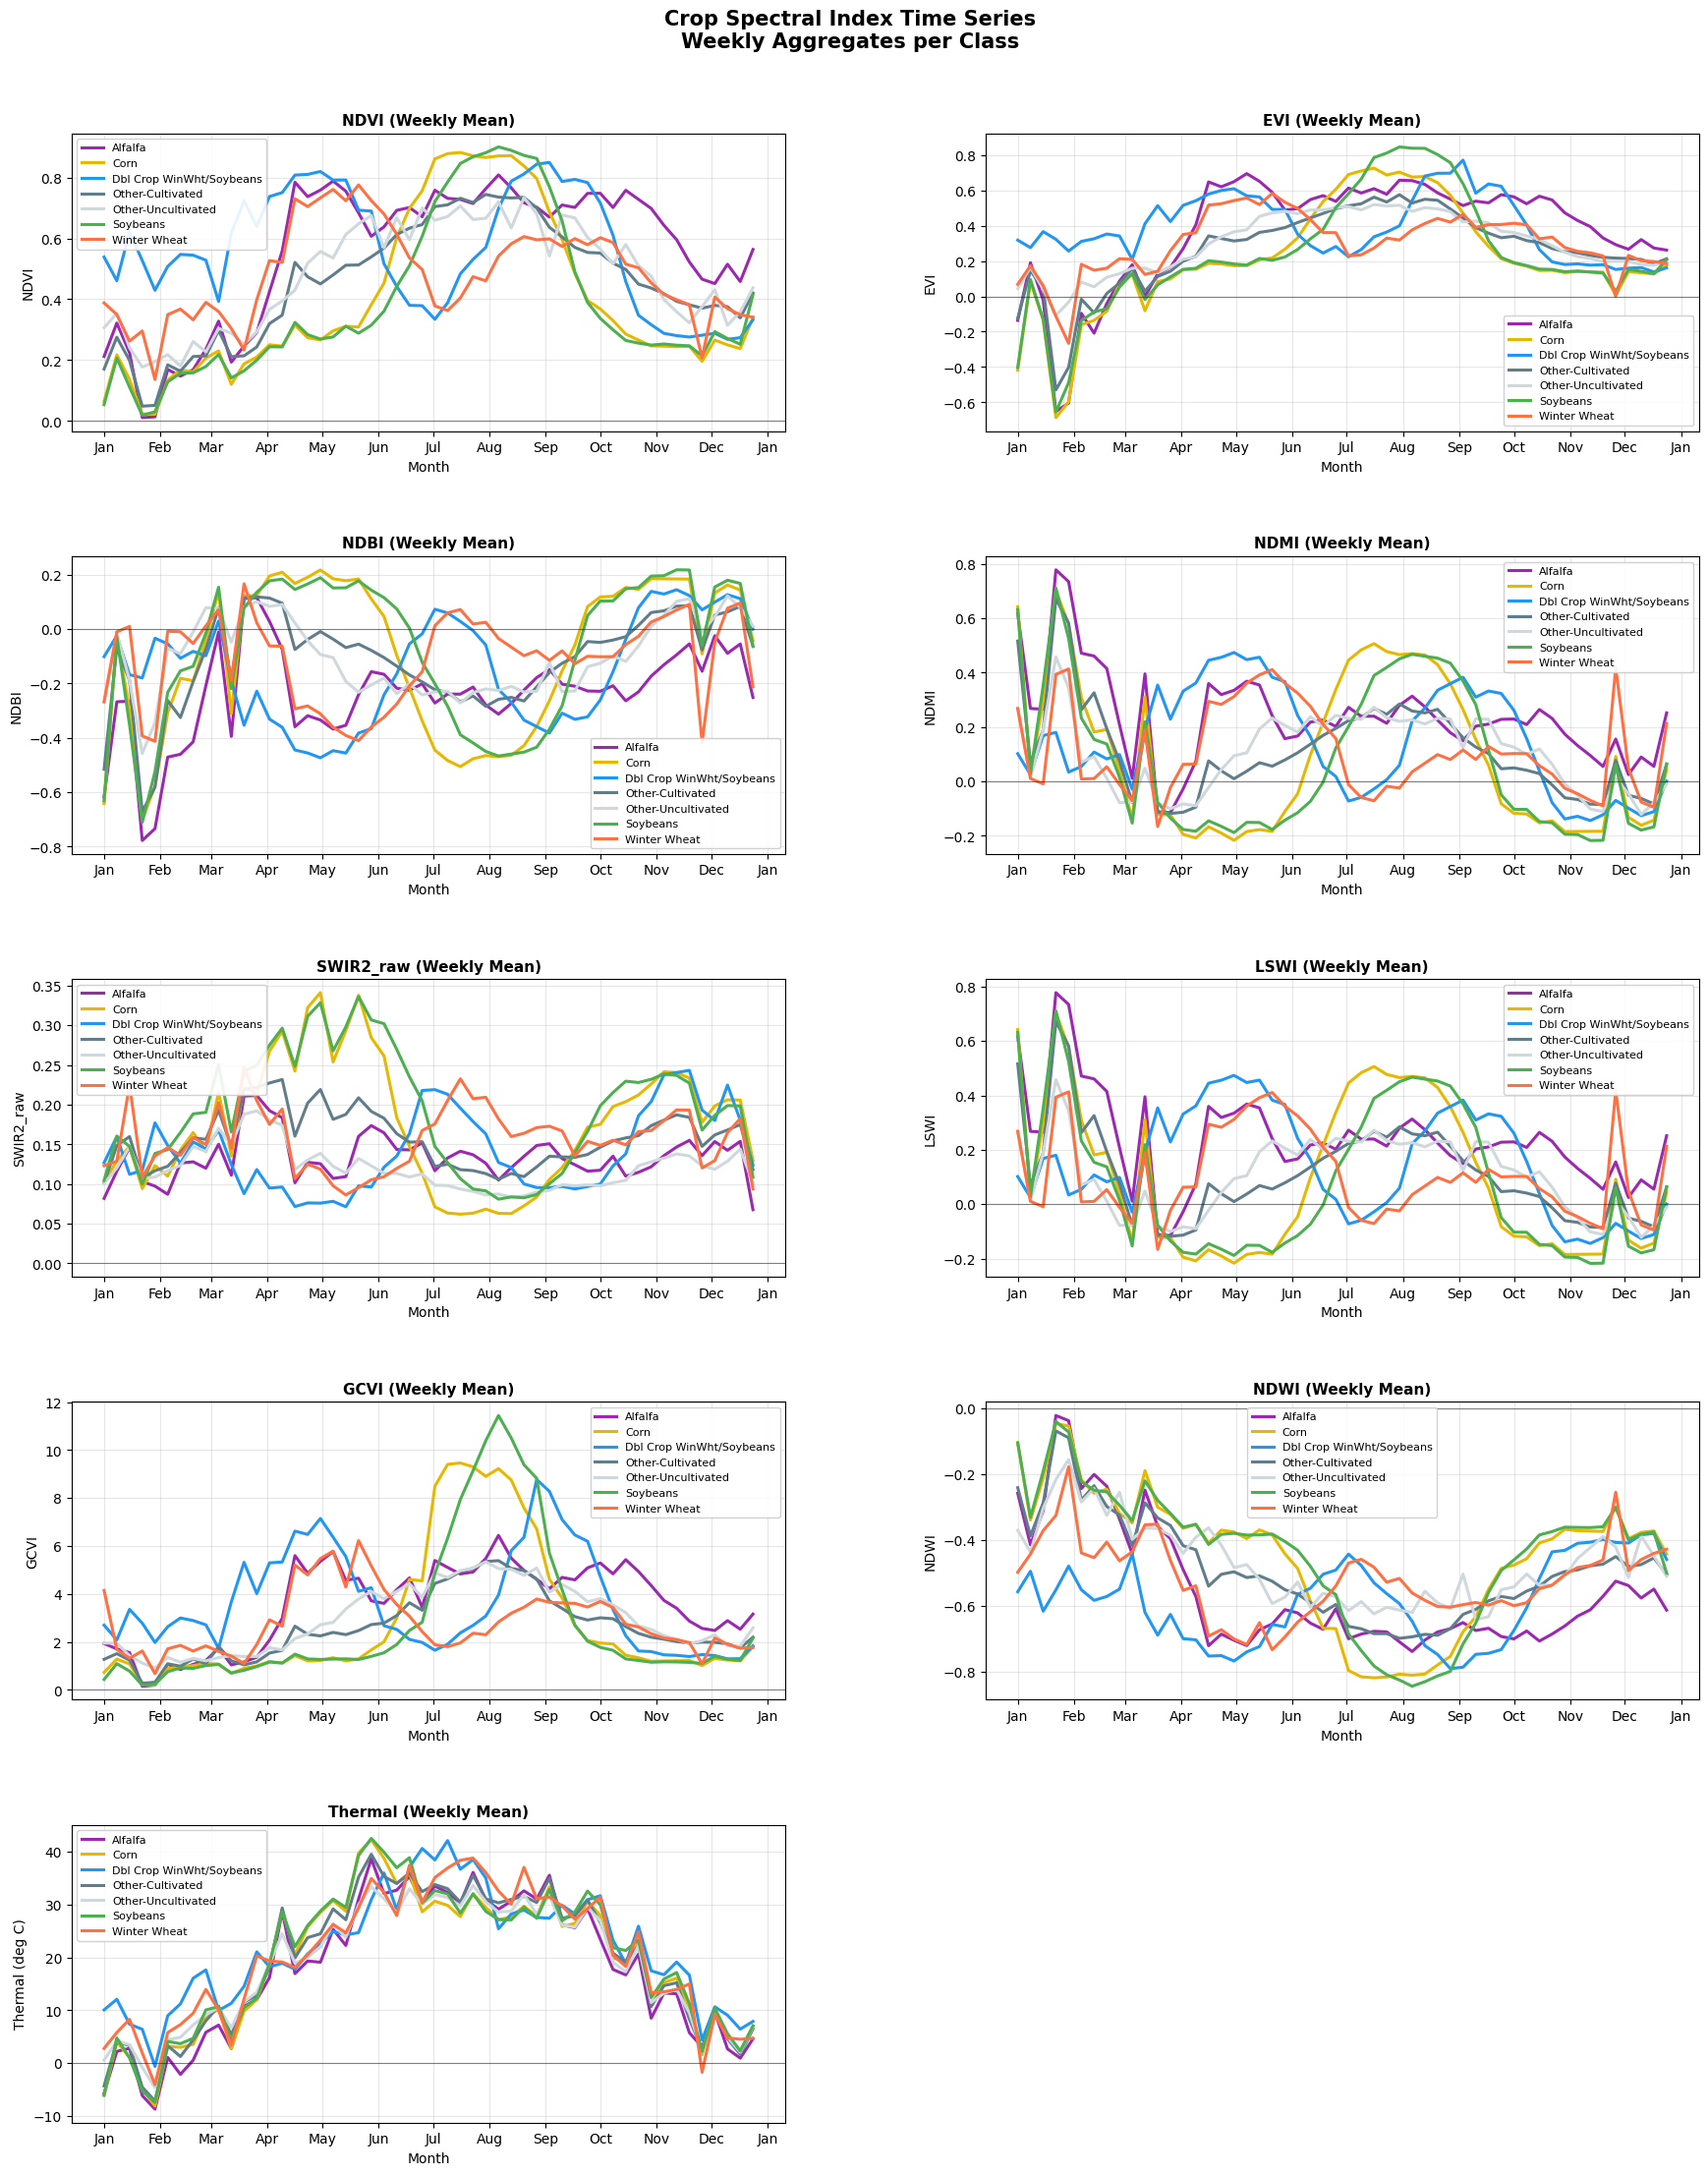

Plot saved to phase2_time_series_weekly.png


In [11]:
# -- Time series plots: weekly mean per crop for all indices --
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Generated some cleaner colors, makes things pop more on the graphs.
CROP_COLORS = {
    'Corn': '#e6b800',
    'Soybeans': '#4caf50',
    'Grass/Pasture': '#8d6e63',
    'Dbl Crop WinWht/Soybeans': '#2196f3',
    'Alfalfa': '#9c27b0',
    'Winter Wheat': '#ff7043',
    'Other-Cultivated': '#607d8b',
    'Other-Uncultivated': '#cfd8dc',
}
# Plot all analysis index bands (Not including the ones we ignored earlier).
INDICES = ANALYSIS_INDEX_COLS.copy()
#
crop_names = sorted(ts_weekly_df['crop_name'].unique().tolist())

# Had some issues with bounds, this cleans those up for GCVI & Thermal
n_indices = len(INDICES)
n_cols = 2
n_rows = math.ceil(n_indices / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 4.6 * n_rows),
    squeeze=False,
    constrained_layout=False,
 )
fig.suptitle(
    'Crop Spectral Index Time Series\nWeekly Aggregates per Class',
    fontsize=15,
    fontweight='bold',
    y=0.995,
 )

for ax, index in zip(axes.flat, INDICES):
    for crop_name in crop_names:
        crop_data = ts_weekly_df[ts_weekly_df['crop_name'] == crop_name].sort_values('date')
        if crop_data.empty:
            continue

        dates = crop_data['date']
        values = crop_data[index]
        ax.plot(
            dates,
            values,
            color=CROP_COLORS[crop_name],
            linewidth=2.2,
            label=crop_name,
        )
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_title(f'{index} (Weekly Mean)', fontweight='bold', fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Thermal (deg C)' if index == 'Thermal' else index)

    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplot axes.
for ax in axes.flat[n_indices:]:
    ax.set_visible(False)

# Increase spacing between panels.
plt.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06, wspace=0.28, hspace=0.42)

plt.savefig('phase2_time_series_weekly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to phase2_time_series_weekly.png')

I think that the hardest crops to find differences between will be corn/soybeans. In general, the rest of the crops have significant variability in at least one index (NDWI, LSWI, and SWIR2 differ for Alfalfa and Winter wheat post June), and the "other" classes seem to differ in the winter relative to the focus classes. However, Corn & Soybeans seem to follow the same general structure with no significant differences between them, barring some amplification of the GCVI for July-September for Soybeans relative to Corn. This is surprising, I had figured that double crop would be the least discernable characteristic, but it appears to have a unique trace over the course of the year that other features simply do not have. It is also surprising that thermal imagery appears to be completely correllated across all classes, including the others. There is minimal thermal pattern variation for different fields (at least visually).


I'm ensuring that my samples cover the entire study region by selecting a subgroup of points, and then finding samples for said points across the span of the entire year. I'm using spatial sampling to guarantee that I process each category equally, preventing the data distribution from removing necessary information.

Noisy & Missing observations are handled with some normalization (If a normalized field explodes, we know sensor readings have failed). I'm currently ignoring them altogether, though this might introduce problems later on.

## Phase 3: Classification System

Objective: Build, train, and rigorously evaluate a pixel-level crop classifier using full-year 2023 Landsat data.

**Deliverables**: Trained model, feature engineering justification, confusion matrix and per-class metrics, error analysis, discussion of model iterations

In [12]:
## Build the data pipeline out for training in the next cell
from sklearn.model_selection import train_test_split

# Use computed index features and build per-point, full-year vectors
# so each sample represents one pixel's seasonal profile.
excluded_features = {}
base_feature_cols = [col for col in ANALYSIS_INDEX_COLS if col not in excluded_features]

required_cols = ['lon', 'lat', 'date', 'crop_name'] + base_feature_cols
missing_cols = [c for c in required_cols if c not in ts_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for modeling: {missing_cols}")

model_df = ts_df[required_cols].copy()
model_df = model_df.dropna(subset=['crop_name'])
model_df['date'] = pd.to_datetime(model_df['date'])
model_df['month'] = model_df['date'].dt.month.astype(int)

# Aggregate to one value per point, per month, per index.
point_month_df = (
    model_df.groupby(['lon', 'lat', 'crop_name', 'month'], as_index=False)[base_feature_cols]
    .mean()
)

# Pivot to wide full-year vectors: <feature>_m01 ... <feature>_m12.
point_wide = point_month_df.pivot_table(
    index=['lon', 'lat', 'crop_name'],
    columns='month',
    values=base_feature_cols,
    aggfunc='mean'
)
point_wide = point_wide.reindex(columns=range(1, 13), level=1)
point_wide.columns = [f"{feat}_m{month:02d}" for feat, month in point_wide.columns]
point_wide = point_wide.reset_index()

feature_cols = [c for c in point_wide.columns if c not in ['lon', 'lat', 'crop_name']]

# Keep points with at least some seasonal signal: Some noise is okay (and likely in part 4)
point_wide = point_wide.dropna(subset=feature_cols, how='all')

class_labels = sorted(point_wide['crop_name'].unique().tolist())

print(f"Prepared point-level dataset with {len(point_wide):,} samples")
print(f"Number of classes: {len(class_labels)}")
print("Class counts:")
print(point_wide['crop_name'].value_counts())
print(f"\nFull-year feature columns: {len(feature_cols)}")

# Split at the point level.
train_df, test_df = train_test_split(
    point_wide,
    test_size=0.2,
    random_state=SEED,
    stratify=point_wide['crop_name'],
)

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['crop_name']
y_test = test_df['crop_name']

print(f"\nTrain/Test Split (stratified, point-level):")
print(f"  Train size: {len(X_train):,}")
print(f"  Test size:  {len(X_test):,}")
print("\nTrain set class counts:")
print(y_train.value_counts())

Prepared point-level dataset with 3,500 samples
Number of classes: 7
Class counts:
crop_name
Alfalfa                     500
Soybeans                    500
Corn                        500
Other-Uncultivated          500
Other-Cultivated            500
Winter Wheat                500
Dbl Crop WinWht/Soybeans    500
Name: count, dtype: int64

Full-year feature columns: 108

Train/Test Split (stratified, point-level):
  Train size: 2,800
  Test size:  700

Train set class counts:
crop_name
Winter Wheat                400
Corn                        400
Other-Uncultivated          400
Soybeans                    400
Alfalfa                     400
Other-Cultivated            400
Dbl Crop WinWht/Soybeans    400
Name: count, dtype: int64


In [13]:
# Phase 3.2: Train Random Forest baseline classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
    ))
])

rf_pipeline.fit(X_train, y_train)

print('Random Forest training complete.')
print(f'Train rows: {len(X_train):,}, Test rows: {len(X_test):,}')
print(f'Feature count: {X_train.shape[1]}')

Random Forest training complete.
Train rows: 2,800, Test rows: 700
Feature count: 108


Test Set overall metrics (raw classes):
  Accuracy:    0.8029
  Macro F1:    0.8047
  Weighted F1: 0.8047
  Micro F1:    0.8029

Test Set per-class precision / recall / F1 (raw classes):
                   class  precision  recall  f1_score  support
                Soybeans     0.8762  0.9200    0.8976      100
Dbl Crop WinWht/Soybeans     0.8679  0.9200    0.8932      100
                 Alfalfa     0.8660  0.8400    0.8528      100
            Winter Wheat     0.8710  0.8100    0.8394      100
                    Corn     0.8542  0.8200    0.8367      100
      Other-Uncultivated     0.8049  0.6600    0.7253      100
        Other-Cultivated     0.5372  0.6500    0.5882      100

Test Set grouped metrics (Other-Cultivated + Other-Uncultivated -> Other):
  Accuracy:    0.8543
  Macro F1:    0.8581
  Weighted F1: 0.8539
  Micro F1:    0.8543

Test Set per-class precision / recall / F1 (grouped):
                   class  precision  recall  f1_score  support
                Soybeans   

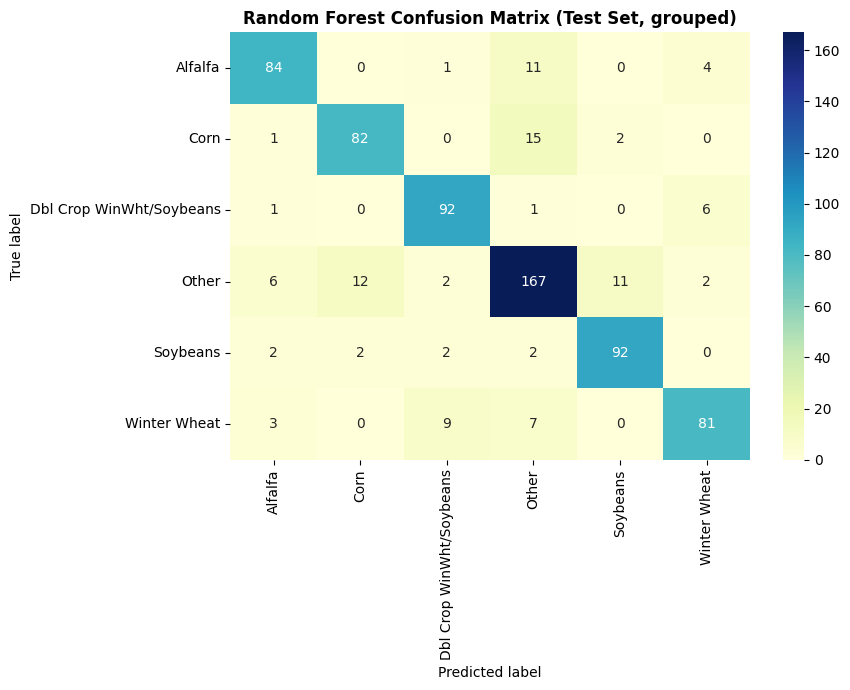

In [14]:
# Phase 3.3: Evaluate model on full dataset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

# Since we're training with two others, we collapse them now for a better picture of evaluation
def collapse_other_label(label):
    if label in ('Other-Cultivated', 'Other-Uncultivated'):
        return 'Other'
    return label


def evaluate_classifier(model, X_eval, y_eval, labels, split_name='Full Dataset'):
    y_pred = model.predict(X_eval)

    # ---------- Raw (full class set) metrics ----------
    cm_raw = confusion_matrix(y_eval, y_pred, labels=labels)

    accuracy_raw = accuracy_score(y_eval, y_pred)
    macro_f1_raw = f1_score(y_eval, y_pred, average='macro')
    weighted_f1_raw = f1_score(y_eval, y_pred, average='weighted')
    micro_f1_raw = f1_score(y_eval, y_pred, average='micro')

    precision, recall, f1, support = precision_recall_fscore_support(
        y_eval,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    metrics_df_raw = pd.DataFrame({
        'class': labels,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support,
    }).sort_values('f1_score', ascending=False)

    print(f'{split_name} overall metrics (raw classes):')
    print(f"  Accuracy:    {accuracy_raw:.4f}")
    print(f"  Macro F1:    {macro_f1_raw:.4f}")
    print(f"  Weighted F1: {weighted_f1_raw:.4f}")
    print(f"  Micro F1:    {micro_f1_raw:.4f}")

    print(f'\n{split_name} per-class precision / recall / F1 (raw classes):')
    print(metrics_df_raw.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

    # ---------- Grouped review metrics (Other-* -> Other) ----------
    y_eval_grouped = pd.Series(y_eval).map(collapse_other_label)
    y_pred_grouped = pd.Series(y_pred).map(collapse_other_label)

    grouped_labels = []
    for lbl in labels:
        collapsed = collapse_other_label(lbl)
        if collapsed not in grouped_labels:
            grouped_labels.append(collapsed)

    cm_grouped = confusion_matrix(y_eval_grouped, y_pred_grouped, labels=grouped_labels)

    accuracy_grouped = accuracy_score(y_eval_grouped, y_pred_grouped)
    macro_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='macro', labels=grouped_labels, zero_division=0)
    weighted_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='weighted', labels=grouped_labels, zero_division=0)
    micro_f1_grouped = f1_score(y_eval_grouped, y_pred_grouped, average='micro', labels=grouped_labels, zero_division=0)

    precision_g, recall_g, f1_g, support_g = precision_recall_fscore_support(
        y_eval_grouped,
        y_pred_grouped,
        labels=grouped_labels,
        zero_division=0,
    )

    metrics_df_grouped = pd.DataFrame({
        'class': grouped_labels,
        'precision': precision_g,
        'recall': recall_g,
        'f1_score': f1_g,
        'support': support_g,
    }).sort_values('f1_score', ascending=False)

    print(f'\n{split_name} grouped metrics (Other-Cultivated + Other-Uncultivated -> Other):')
    print(f"  Accuracy:    {accuracy_grouped:.4f}")
    print(f"  Macro F1:    {macro_f1_grouped:.4f}")
    print(f"  Weighted F1: {weighted_f1_grouped:.4f}")
    print(f"  Micro F1:    {micro_f1_grouped:.4f}")

    print(f'\n{split_name} per-class precision / recall / F1 (grouped):')
    print(metrics_df_grouped.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

    print(f'\n{split_name} classification report (grouped):')
    print(classification_report(y_eval_grouped, y_pred_grouped, labels=grouped_labels, zero_division=0))

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm_grouped,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        xticklabels=grouped_labels,
        yticklabels=grouped_labels,
    )
    plt.title(f'Random Forest Confusion Matrix ({split_name}, grouped)', fontweight='bold')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

    return y_pred, cm_grouped, metrics_df_grouped, {
        'accuracy': accuracy_grouped,
        'macro_f1': macro_f1_grouped,
        'weighted_f1': weighted_f1_grouped,
        'micro_f1': micro_f1_grouped,
    }, grouped_labels


# Evaluate on test set
rf_y_pred, rf_cm, rf_class_metrics_df, rf_overall_metrics, grouped_class_labels = evaluate_classifier(
    rf_pipeline,
    X_test,
    y_test,
    class_labels,
    split_name='Test Set',
)

# Aliases for Cell 18 error analysis (backward compatibility)
cm = rf_cm
class_metrics_df = rf_class_metrics_df
overall_metrics = rf_overall_metrics

In [15]:
# Phase 3.4: Error analysis (grouped Other classes)

# Identify the most frequent misclassifications from the grouped confusion matrix.
cm_df = pd.DataFrame(cm, index=grouped_class_labels, columns=grouped_class_labels)

error_rows = []
for true_label in grouped_class_labels:
    for pred_label in grouped_class_labels:
        if true_label != pred_label:
            count = int(cm_df.loc[true_label, pred_label])
            if count > 0:
                error_rows.append({
                    'true_class': true_label,
                    'predicted_as': pred_label,
                    'count': count,
                })

if error_rows:
    error_df = pd.DataFrame(error_rows).sort_values('count', ascending=False)
    print('Top misclassifications (grouped labels):')
    print(error_df.head(10).to_string(index=False))
else:
    print('No off-diagonal errors found in grouped confusion matrix.')

lowest_recall_row = class_metrics_df.sort_values('recall', ascending=True).iloc[0]
print(
    f"\nLowest-recall grouped class: {lowest_recall_row['class']} "
    f"(recall={lowest_recall_row['recall']:.4f}, f1={lowest_recall_row['f1_score']:.4f})"
)

# Feature importances listed from least important to most important.
rf_model = rf_pipeline.named_steps['model']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=True)

print('\nFeature importances (least -> most important):')
print(importance_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

print('\nLeast important features first:')
print(importance_df['feature'].tolist())

Top misclassifications (grouped labels):
              true_class             predicted_as  count
                    Corn                    Other     15
                   Other                     Corn     12
                 Alfalfa                    Other     11
                   Other                 Soybeans     11
            Winter Wheat Dbl Crop WinWht/Soybeans      9
            Winter Wheat                    Other      7
Dbl Crop WinWht/Soybeans             Winter Wheat      6
                   Other                  Alfalfa      6
                 Alfalfa             Winter Wheat      4
            Winter Wheat                  Alfalfa      3

Lowest-recall grouped class: Winter Wheat (recall=0.8100, f1=0.8394)

Feature importances (least -> most important):
      feature  importance
     NDMI_m03      0.0025
     LSWI_m03      0.0025
     NDBI_m03      0.0025
     NDWI_m03      0.0026
     NDVI_m03      0.0027
     GCVI_m03      0.0027
      EVI_m03      0.0032
  Ther

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Train MLP on the full tabular dataset (same split as Random Forest).
# This avoids restricting MLP to only pixels with complete 12-month profiles.
print(f"Using full RF split for MLP:")
print(f"  Train rows: {len(X_train):,}")
print(f"  Test rows:  {len(X_test):,}")
print(f"  Num features: {X_train.shape[1]}")

# --- Preprocess: fit only on train to avoid leakage ---
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_proc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_test_proc = scaler.transform(X_test_imp).astype(np.float32)

# Label encoding aligned with class_labels from Phase 3.1
le = LabelEncoder()
le.fit(class_labels)
y_train_int = le.transform(y_train)
y_test_int = le.transform(y_test)
n_classes = len(le.classes_)

# Treat the tabular feature vector as a 1D sequence with 1 channel.
# MLP will flatten this internally.
train_X_t = torch.from_numpy(X_train_proc).unsqueeze(1)
test_X_t = torch.from_numpy(X_test_proc).unsqueeze(1)
train_y_t = torch.from_numpy(y_train_int.astype(np.int64))
test_y_t = torch.from_numpy(y_test_int.astype(np.int64))

train_dataset = TensorDataset(train_X_t, train_y_t)
test_dataset = TensorDataset(test_X_t, test_y_t)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class TabularMLP(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128):
        super(TabularMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(n_features, hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size),
            nn.Dropout(0.25),
            nn.Linear(hidden_size, n_classes)
        )

    def forward(self, x):
        # Input shape will be (batch_size, 1, n_features) from unsqueeze(1)
        # Flatten to (batch_size, n_features) for linear layers
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nTraining on: {device}")

# Instantiate the MLP model
mlp_model = TabularMLP(n_features=X_train.shape[1], n_classes=n_classes, hidden_size=128).to(device)

mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"MLP trainable parameters: {mlp_params:,}")
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# --- Training loop ---
N_EPOCHS = 250
for epoch in range(1, N_EPOCHS + 1):
    mlp_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = mlp_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += X_batch.size(0)

    avg_loss = total_loss / total if total > 0 else 0
    train_acc = correct / total if total > 0 else 0

    if epoch % 10 == 0:
        print(f"Epoch {epoch:>2}/{N_EPOCHS}  loss={avg_loss:.4f}  train_acc={train_acc:.4f}")

# --- MLP Evaluation ---
mlp_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = mlp_model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

mlp_y_pred_names = le.inverse_transform(np.array(all_preds))
mlp_y_true_names = le.inverse_transform(np.array(all_true))

# Group the two Other subclasses for reporting consistency.
mlp_y_pred_grouped = pd.Series(mlp_y_pred_names).map(collapse_other_label)
mlp_y_true_grouped = pd.Series(mlp_y_true_names).map(collapse_other_label)

mlp_accuracy = accuracy_score(mlp_y_true_grouped, mlp_y_pred_grouped)
mlp_macro_f1 = f1_score(mlp_y_true_grouped, mlp_y_pred_grouped, average='macro', labels=grouped_class_labels, zero_division=0)
mlp_cm = confusion_matrix(mlp_y_true_grouped, mlp_y_pred_grouped, labels=grouped_class_labels)

print(f"\nMLP Test Results (grouped Other classes):")
print(f"  Accuracy:  {mlp_accuracy:.4f}")
print(f"  Macro F1:  {mlp_macro_f1:.4f}")
print(f"\nClassification Report (grouped):")
print(classification_report(mlp_y_true_grouped, mlp_y_pred_grouped, labels=grouped_class_labels, zero_division=0))

Using full RF split for MLP:
  Train rows: 2,800
  Test rows:  700
  Num features: 108

Training on: cuda
MLP trainable parameters: 15,111
Epoch 10/250  loss=0.5880  train_acc=0.8007
Epoch 20/250  loss=0.4862  train_acc=0.8346
Epoch 30/250  loss=0.4243  train_acc=0.8493
Epoch 40/250  loss=0.3776  train_acc=0.8668
Epoch 50/250  loss=0.3200  train_acc=0.8886
Epoch 60/250  loss=0.2682  train_acc=0.9068
Epoch 70/250  loss=0.2446  train_acc=0.9182
Epoch 80/250  loss=0.2207  train_acc=0.9229
Epoch 90/250  loss=0.1899  train_acc=0.9361
Epoch 100/250  loss=0.1671  train_acc=0.9450
Epoch 110/250  loss=0.1496  train_acc=0.9486
Epoch 120/250  loss=0.1379  train_acc=0.9568
Epoch 130/250  loss=0.1338  train_acc=0.9525
Epoch 140/250  loss=0.1163  train_acc=0.9618
Epoch 150/250  loss=0.1165  train_acc=0.9604
Epoch 160/250  loss=0.0992  train_acc=0.9664
Epoch 170/250  loss=0.1113  train_acc=0.9586
Epoch 180/250  loss=0.0970  train_acc=0.9639
Epoch 190/250  loss=0.0873  train_acc=0.9686
Epoch 200/250  

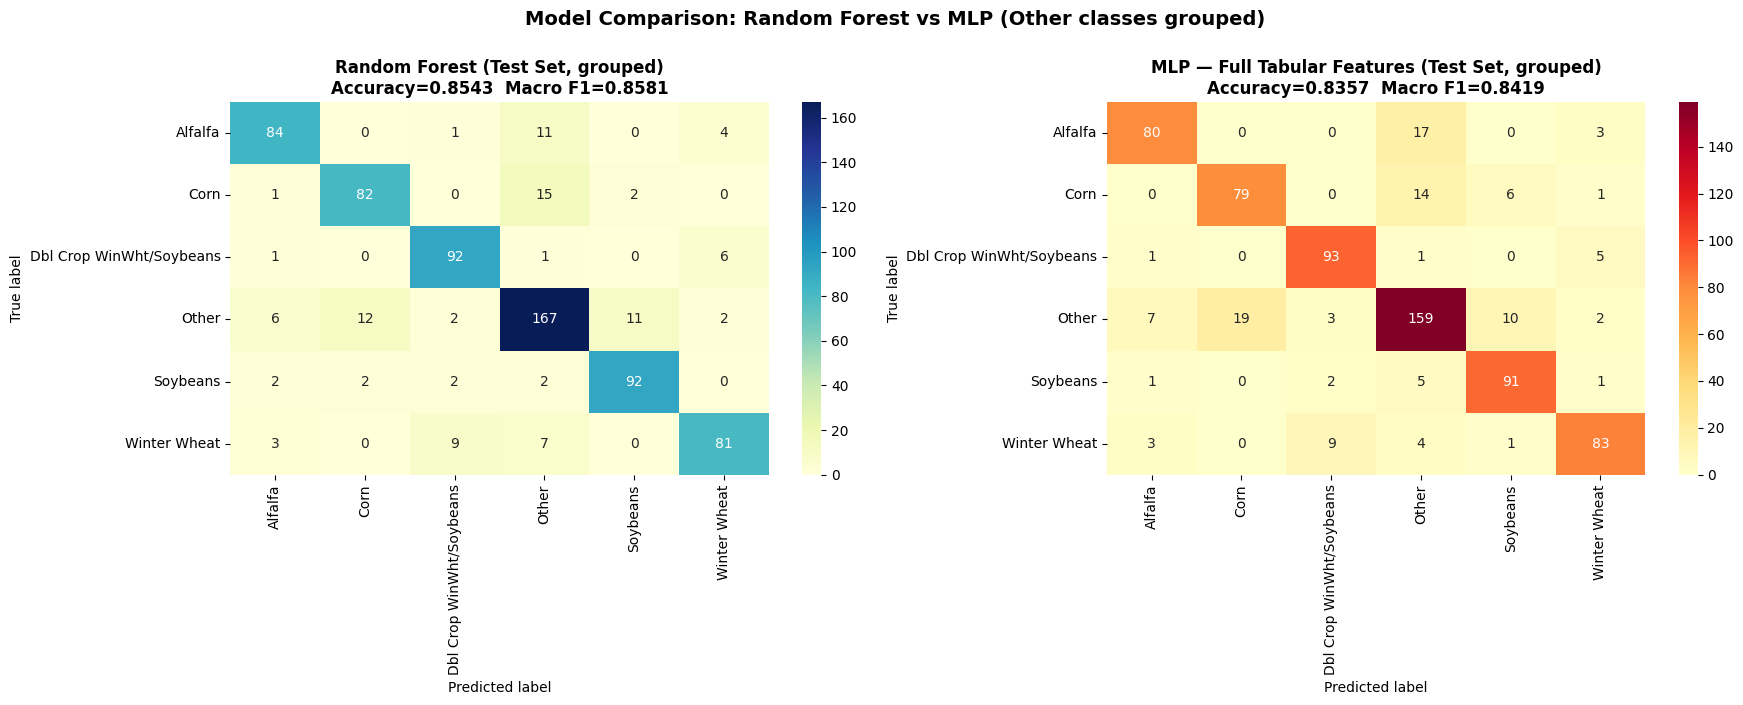


Model Summary: RandomForest vs MLP (Grouped Other)
Model                       Accuracy   Macro F1
---------------------------------------------
Random Forest                 0.8543     0.8581
MLP (Full Tabular)            0.8357     0.8419


In [17]:
# Phase 3.6: Side-by-side confusion matrix — Random Forest vs MLP

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- RF confusion matrix (left, grouped Other classes) ---
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=grouped_class_labels,
    yticklabels=grouped_class_labels,
    ax=ax1,
)
ax1.set_title(
    f'Random Forest (Test Set, grouped)\nAccuracy={rf_overall_metrics["accuracy"]:.4f}  'f'Macro F1={rf_overall_metrics["macro_f1"]:.4f}',
    fontweight='bold',
    fontsize=12,
)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')

# --- MLP confusion matrix (right, grouped Other classes) ---
sns.heatmap(
    mlp_cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=grouped_class_labels,
    yticklabels=grouped_class_labels,
    ax=ax2,
)
ax2.set_title(
    f'MLP — Full Tabular Features (Test Set, grouped)\nAccuracy={mlp_accuracy:.4f}  'f'Macro F1={mlp_macro_f1:.4f}',
    fontweight='bold',
    fontsize=12,
)
ax2.set_xlabel('Predicted label')
ax2.set_ylabel('True label')

plt.suptitle('Model Comparison: Random Forest vs MLP (Other classes grouped)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary comparison table
print("\n" + "="*50)
print("Model Summary: RandomForest vs MLP (Grouped Other)")
print("="*50)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'-'*45}")
print(f"{'Random Forest':<25} {rf_overall_metrics['accuracy']:>10.4f} {rf_overall_metrics['macro_f1']:>10.4f}")
print(f"{'MLP (Full Tabular)':<25} {mlp_accuracy:>10.4f} {mlp_macro_f1:>10.4f}")
print("="*50)

## Phase 4: Deployment and Generalization

Objective: Apply the trained model to 2024 imagery in two counties (one within training region, one outside) and assess generalization.

**Deliverables**: 30m classification maps for McLean County, IL and Renville County, MN; visual comparison with 2024 CDL; generalization analysis

In [18]:
# Phase 4.1: Deployment setup using Part 3 trained models (no retraining here)


# Reuse models from Phase 3.
TOP5_CODES = [int(c) for c in CODES.values()]
TOP5_NAMES = [name for name in CODES.keys()]
TOP5_LABELS = list(range(1, len(TOP5_CODES) + 1))
LABEL_TO_NAME = {lbl: name for lbl, name in zip(TOP5_LABELS, TOP5_NAMES)}



def get_county_geometry(state_fips, county_name):
    county = (counties_fc
              .filter(ee.Filter.eq('STATEFP', state_fips))
              .filter(ee.Filter.eq('NAME', county_name))
              .first())
    return ee.Feature(county).geometry()

counties_fc = ee.FeatureCollection('TIGER/2018/Counties')
MCLEAN_GEOM = get_county_geometry('17', 'McLean')
RENVILLE_GEOM = get_county_geometry('27', 'Renville')

TOTAL_REGION = MCLEAN_GEOM.union(RENVILLE_GEOM)

# Load landsat for these regions for 2024.
landsat_2024 = prep_landsat(l8.merge(l9), '2024-01-01', '2024-12-31',
                             TOTAL_REGION)

landsat_2024_indexed = landsat_2024.map(add_indices)
landsat_size = landsat_2024.size().getInfo()
print(f"Number of Landsat scenes for 2024: {landsat_size}")

collection = ee.ImageCollection('USDA/NASS/CDL').filter(ee.Filter.eq('system:index', '2024'))
cdl = collection.first()

# The 2024 CDL exposes cropland directly, so clip that band for county visualizations and exports.
mclean_cdl = cdl.select('cropland').clip(MCLEAN_GEOM)
renville_cdl = cdl.select('cropland').clip(RENVILLE_GEOM)
truth_2024_top5 = cdl.select('cropland').remap(TOP5_CODES, TOP5_LABELS).rename('truth_2024_top5').updateMask(cdl.select('cropland').remap(TOP5_CODES, TOP5_LABELS).gt(0))



# This is a little wonky, was having besteffort issues for cdl area.
# Grabs pixels in region that are cultivated, groups by crop code.
area_image = ee.Image.pixelArea().divide(1e6).rename('area_km2').addBands(cdl_clipped)
area_grouped = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='crop_code'),
    geometry=STUDY_REGION,
    scale=30,
    maxPixels=1e13
 )
groups = area_grouped.get('groups').getInfo()

Number of Landsat scenes for 2024: 174


In [19]:
# Phase 4.2: CDL map rendering consistent with Phase 1
from geemap import core
import geemap.coreutils as geemap_coreutils
from ipyleaflet import WidgetControl
import ipywidgets as widgets

# Use the same top-5 palette as Phase 1 so the county maps stay visually consistent.
top5_palette = ['#f4d03f', '#2ecc71', '#5dade2', '#e74c3c', '#9b59b6']

# Build categorical top-5 CDL layers for each county independently.
mclean_top5 = mclean_cdl.remap(TOP5_CODES, TOP5_LABELS).updateMask(mclean_cdl.remap(TOP5_CODES, TOP5_LABELS).gt(0))
renville_top5 = renville_cdl.remap(TOP5_CODES, TOP5_LABELS).updateMask(renville_cdl.remap(TOP5_CODES, TOP5_LABELS).gt(0))

# Build county boundary layers for readability.
mclean_geom_layer = ee.FeatureCollection([ee.Feature(MCLEAN_GEOM)]).style(
    color='0000FF',
    fillColor='00000000',
    width=2,
)
renville_geom_layer = ee.FeatureCollection([ee.Feature(RENVILLE_GEOM)]).style(
    color='FF0000',
    fillColor='00000000',
    width=2,
)

# Avoid Colab-secret API-key lookup timeout in non-Colab notebook environments.
geemap_coreutils.get_google_maps_api_key = lambda key='GOOGLE_MAPS_API_KEY': None
m = core.Map(center=[45, -91.0], zoom=5)

m.addLayer(mclean_top5, {'min': 1, 'max': 5, 'palette': top5_palette}, 'McLean 2024 CDL - Top 5')
m.addLayer(renville_top5, {'min': 1, 'max': 5, 'palette': top5_palette}, 'Renville 2024 CDL - Top 5')
m.addLayer(mclean_geom_layer, {}, 'McLean County IL Boundary')
m.addLayer(renville_geom_layer, {}, 'Renville County MN Boundary')

# Match the Phase 1 legend pattern for the shared top-5 crop classes.
legend_items = list(zip(TOP5_NAMES, top5_palette))
legend_rows = []
for label, color in legend_items:
    legend_rows.append(
        f"<div style='display:flex; align-items:center; margin:2px 0;'>"
        f"<span style='display:inline-block; width:12px; height:12px; background:{color}; margin-right:8px; border:1px solid #333;'></span>"
        f"<span style='font-size:12px;'>{label}</span>"
        f"</div>"
    )

legend_html = (
    "<div style='background:white; padding:8px 10px; border:1px solid #999; border-radius:4px;'>"
    "<div style='font-weight:600; margin-bottom:6px;'>Top-5 Crop Classes</div>"
    + "".join(legend_rows) +
    "</div>"
)

legend_widget = widgets.HTML(value=legend_html)
m.add(WidgetControl(widget=legend_widget, position='bottomright'))

m

Map(center=[45, -91.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_…

In [20]:
# Phase 4.3: Build/export 2024 county feature stacks using the Phase 2 Landsat pipeline
import os
import pandas as pd

EXPORT_FOLDER = 'ECE414_Assignment2_Maps'
drive_export_dir = os.path.join(drive_root, 'MyDrive', EXPORT_FOLDER)
os.makedirs(drive_export_dir, exist_ok=True)

print(f'Drive mounted at: {drive_root}')
print(f'Export folder: {drive_export_dir}')

print('\nChecking Drive for existing files...')
existing = os.listdir(drive_export_dir)
for f in sorted(existing):
    size_gb = os.path.getsize(os.path.join(drive_export_dir, f)) / (1024 ** 3)
    print(f'  {f:<60} {size_gb:.2f} GB')


def build_monthly_feature_stack(indexed_collection, region, year=2024, index_cols=None):
    """Build monthly mean stack with Phase 3-compatible band names: <feature>_m01..m12."""
    if index_cols is None:
        index_cols = ANALYSIS_INDEX_COLS

    monthly_images = []
    for month in range(1, 13):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, 'month')

        monthly_mean = indexed_collection.filterDate(start, end).mean().select(index_cols)
        monthly_renamed = monthly_mean.rename([f'{band}_m{month:02d}' for band in index_cols])
        monthly_images.append(monthly_renamed)

    return ee.Image.cat(monthly_images).clip(region)


# Reuse Phase 2 prep pipeline directly for each county in 2024.
landsat_2024_mclean = prep_landsat(l8.merge(l9), '2024-01-01', '2024-12-31', MCLEAN_GEOM).map(add_indices)
landsat_2024_renville = prep_landsat(l8.merge(l9), '2024-01-01', '2024-12-31', RENVILLE_GEOM).map(add_indices)

print(f"\nMcLean scenes (2024, post-mask/scale): {landsat_2024_mclean.size().getInfo():,}")
print(f"Renville scenes (2024, post-mask/scale): {landsat_2024_renville.size().getInfo():,}")

features_2024_mclean = build_monthly_feature_stack(landsat_2024_mclean, MCLEAN_GEOM, year=2024)
features_2024_renville = build_monthly_feature_stack(landsat_2024_renville, RENVILLE_GEOM, year=2024)

print(f"McLean feature band count: {len(features_2024_mclean.bandNames().getInfo())}")
print(f"Renville feature band count: {len(features_2024_renville.bandNames().getInfo())}")


def queue_image_export(image, description, file_prefix, region_geom):
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder=EXPORT_FOLDER,
        fileNamePrefix=file_prefix,
        region=region_geom,
        scale=30,
        maxPixels=1e13,
        fileFormat='GeoTIFF',
    )
    task.start()
    return task.id


job_specs = [
    ('mclean_features_2024', features_2024_mclean, MCLEAN_GEOM),
    ('renville_features_2024', features_2024_renville, RENVILLE_GEOM),
]

status_rows = []
for prefix, image, geom in job_specs:
    already_exists = any(prefix in fname for fname in existing)
    if already_exists:
        status_rows.append({
            'Export': prefix,
            'State': 'FILE_AVAILABLE',
            'TaskID': '',
            'Action': 'skip_queue',
        })
    else:
        task_id = queue_image_export(
            image=image,
            description=f'A2_{prefix}',
            file_prefix=prefix,
            region_geom=geom,
        )
        status_rows.append({
            'Export': prefix,
            'State': 'QUEUED',
            'TaskID': task_id,
            'Action': 'queued_export',
        })

export_status_df = pd.DataFrame(status_rows)
display(export_status_df)

print('\nIf any exports are QUEUED, monitor them in the Earth Engine Tasks tab and rerun this cell after completion.')

Drive mounted at: /content/drive
Export folder: /content/drive/MyDrive/ECE414_Assignment2_Maps

Checking Drive for existing files...
  A2_McLean_2024_feature_stack-0000000000-0000000000.tif       2.02 GB
  A2_McLean_2024_feature_stack-0000000000-0000002816.tif       0.11 GB
  A2_McLean_2024_truth_top5_v3.tif                             0.00 GB
  A2_Renville_2024_feature_stack-0000000000-0000000000.tif     1.55 GB
  A2_Renville_2024_feature_stack-0000000000-0000002816.tif     0.49 GB
  A2_Renville_2024_truth_top5_v3.tif                           0.00 GB
  mclean_features_2024-0000000000-0000000000.tif               2.40 GB
  mclean_features_2024-0000000000-0000002304.tif               0.68 GB
  phase4_job_ids.json                                          0.00 GB
  renville_features_2024-0000000000-0000000000.tif             1.64 GB
  renville_features_2024-0000000000-0000002304.tif             1.31 GB

McLean scenes (2024, post-mask/scale): 70
Renville scenes (2024, post-mask/scale): 10

,Export,State,TaskID,Action
0,mclean_features_2024,FILE_AVAILABLE,,skip_queue
1,renville_features_2024,FILE_AVAILABLE,,skip_queue



If any exports are QUEUED, monitor them in the Earth Engine Tasks tab and rerun this cell after completion.


## Phase 4.4: Inference on 2024 County Data

This section tests the Part 3 trained models directly on 2024 McLean and Renville samples from the new feature stacks. It reports quick holdout-style county metrics and visualizes both confusion behavior and spatial prediction patterns.

In [24]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score

FULL = False
OTHER_CLASS_CODE = 999
OTHER_CLASS_NAME = 'Other'
FULL_TILE_GRID = 12


def get_active_export_task_count():
    """Return number of currently RUNNING/READY Earth Engine tasks."""
    active_states = {'RUNNING', 'READY'}
    task_list = ee.batch.Task.list()
    return sum(1 for t in task_list if t.status().get('state') in active_states)



def build_county_truth_code_image():
    """Build a county truth image using cropland only: top-5 codes plus Other."""
    cropland = cdl.select('cropland')
    truth_code = ee.Image.constant(OTHER_CLASS_CODE).rename('truth_code').toInt16()
    for crop_code in TOP5_CODES:
        truth_code = truth_code.where(cropland.eq(int(crop_code)), int(crop_code))
    return truth_code



def build_tile_geometries(county_geom, grid_size=12):
    """Create a simple grid covering the county bounds for chunked full-pixel sampling."""
    bounds = county_geom.bounds().coordinates().getInfo()[0]
    xs = [coord[0] for coord in bounds]
    ys = [coord[1] for coord in bounds]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    x_edges = np.linspace(min_x, max_x, grid_size + 1)
    y_edges = np.linspace(min_y, max_y, grid_size + 1)

    tiles = []
    for row_index in range(grid_size):
        for col_index in range(grid_size):
            tile = ee.Geometry.Rectangle([
                float(x_edges[col_index]),
                float(y_edges[row_index]),
                float(x_edges[col_index + 1]),
                float(y_edges[row_index + 1]),
            ], proj=None, geodesic=False)
            tile = tile.intersection(county_geom, ee.ErrorMargin(1))
            tiles.append(tile)
    return tiles



def sample_county_features_for_inference(county_name, county_geom, feature_image, full=FULL, sample_size=2400, seed=95):
    """County inference sampling or full-pixel extraction using cropland truth labels."""
    truth_img = build_county_truth_code_image()

    sample_img = (
        feature_image.select(feature_cols)
        .addBands(truth_img)
        .addBands(ee.Image.pixelLonLat())
    )

    frames = []
    if full:
        tile_geometries = build_tile_geometries(county_geom, grid_size=FULL_TILE_GRID)
        for tile_index, tile_geom in enumerate(tile_geometries):
            tile_fc = sample_img.sample(
                region=tile_geom,
                scale=30,
                seed=seed + tile_index,
                geometries=False,
                dropNulls=False,
                tileScale=16,
            )
            tile_df = geemap.ee_to_df(tile_fc)
            if not tile_df.empty:
                frames.append(tile_df)
    else:
        # Modified to use non-stratified sampling with numPixels
        county_fc = sample_img.sample(
            region=county_geom,
            scale=30,
            numPixels=sample_size,  # Use sample_size directly here for non-stratified sampling
            seed=seed,
            geometries=False,
            dropNulls=False,
            tileScale=4,
        )
        tile_df = geemap.ee_to_df(county_fc)
        if not tile_df.empty:
            frames.append(tile_df)

    if not frames:
        raise RuntimeError(f'No valid sampled pixels returned for {county_name}.')

    df = pd.concat(frames, ignore_index=True)

    df['truth_code'] = pd.to_numeric(df['truth_code'], errors='coerce').astype('Int64')
    df = df[df['truth_code'].isin(sorted(TOP5_CODES + [OTHER_CLASS_CODE]))].copy()

    for col in feature_cols + ['longitude', 'latitude']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['truth_code', 'longitude', 'latitude'])
    df = df[df[feature_cols].notna().any(axis=1)].copy()
    df = df.drop_duplicates(subset=['longitude', 'latitude', 'truth_code'])
    df['truth_name'] = df['truth_code'].apply(lambda code: val_to_name.get(str(int(code)), OTHER_CLASS_NAME) if int(code) != OTHER_CLASS_CODE else OTHER_CLASS_NAME)
    return df



def predict_with_mlp(features_df):
    """Run MLP inference using the same preprocessing fitted in Phase 3."""
    X_imp = imputer.transform(features_df)
    X_scaled = scaler.transform(X_imp).astype(np.float32)
    X_t = torch.from_numpy(X_scaled).unsqueeze(1).to(device)

    mlp_model.eval()
    with torch.no_grad():
        pred_ids = mlp_model(X_t).argmax(dim=1).cpu().numpy()

    return le.inverse_transform(pred_ids)


active_export_tasks = get_active_export_task_count()
if FULL:
    adaptive_sample_size = None
    print(f'FULL=True: running inference on every valid county pixel using a {FULL_TILE_GRID}x{FULL_TILE_GRID} tile grid.')
else:
    # Changed sample size to 10,000 for non-stratified sampling
    adaptive_sample_size = 10000
    if active_export_tasks > 0:
        print(f'Active EE tasks detected: {active_export_tasks}. Using reduced non-stratified sample size ({adaptive_sample_size}) while exports run.')
    else:
        print(f'No active EE export tasks detected. Using non-stratified inference sample size {adaptive_sample_size}.')

county_specs = [
    ('McLean County, IL', MCLEAN_GEOM, features_2024_mclean),
    ('Renville County, MN', RENVILLE_GEOM, features_2024_renville),
]

county_results = {}
inference_summary = []
for county_name, county_geom, county_features in county_specs:
    print(f'\n===== Running 2024 inference for {county_name} =====')

    county_df = sample_county_features_for_inference(
        county_name=county_name,
        county_geom=county_geom,
        feature_image=county_features,
        full=FULL,
        sample_size=adaptive_sample_size, # This will now be 10000
        seed=SEED,
    )

    X_county = county_df[feature_cols]
    county_df['rf_pred_name'] = rf_pipeline.predict(X_county)
    county_df['mlp_pred_name'] = predict_with_mlp(X_county)

    county_df['truth_grouped'] = county_df['truth_name'].map(collapse_other_label)
    county_df['rf_pred_grouped'] = county_df['rf_pred_name'].map(collapse_other_label)
    county_df['mlp_pred_grouped'] = county_df['mlp_pred_name'].map(collapse_other_label)

    grouped_labels = TOP5_NAMES + [OTHER_CLASS_NAME]
    rf_acc = accuracy_score(county_df['truth_grouped'], county_df['rf_pred_grouped'])
    rf_macro_f1 = f1_score(county_df['truth_grouped'], county_df['rf_pred_grouped'], average='macro', labels=grouped_labels, zero_division=0)
    mlp_acc = accuracy_score(county_df['truth_grouped'], county_df['mlp_pred_grouped'])
    mlp_macro_f1 = f1_score(county_df['truth_grouped'], county_df['mlp_pred_grouped'], average='macro', labels=grouped_labels, zero_division=0)

    print(f'[{county_name} | RF]  Accuracy={rf_acc:.4f}  MacroF1={rf_macro_f1:.4f}')
    print(f'[{county_name} | MLP] Accuracy={mlp_acc:.4f}  MacroF1={mlp_macro_f1:.4f}')

    county_results[county_name] = county_df
    inference_summary.append({
        'County': county_name,
        'Samples': len(county_df),
        'RF_Accuracy': rf_acc,
        'RF_MacroF1': rf_macro_f1,
        'MLP_Accuracy': mlp_acc,
        'MLP_MacroF1': mlp_macro_f1,
    })

inference_summary_df = pd.DataFrame(inference_summary)
print('\n=== 2024 County Inference Summary ===')
display(inference_summary_df)
print('Run the next cell to generate confusion heatmaps and geemap agreement maps.')

No active EE export tasks detected. Using non-stratified inference sample size 10000.

===== Running 2024 inference for McLean County, IL =====
[McLean County, IL | RF]  Accuracy=0.7689  MacroF1=0.4959
[McLean County, IL | MLP] Accuracy=0.5627  MacroF1=0.3041

===== Running 2024 inference for Renville County, MN =====
[Renville County, MN | RF]  Accuracy=0.6680  MacroF1=0.4313
[Renville County, MN | MLP] Accuracy=0.4510  MacroF1=0.2357

=== 2024 County Inference Summary ===


,County,Samples,RF_Accuracy,RF_MacroF1,MLP_Accuracy,MLP_MacroF1
0,"McLean County, IL",9990,0.77,0.50,0.56,0.30
1,"Renville County, MN",9988,0.67,0.43,0.45,0.24


Run the next cell to generate confusion heatmaps and geemap agreement maps.



[McLean County, IL] RF classification report
                          precision    recall  f1-score   support

                 Alfalfa       0.60      0.81      0.69       400
                    Corn       0.96      0.55      0.70       400
Dbl Crop WinWht/Soybeans       0.58      0.35      0.44       400
                   Other       0.46      0.90      0.61       400
                Soybeans       0.74      0.93      0.83       400
            Winter Wheat       0.48      0.14      0.21       400

                accuracy                           0.61      2400
               macro avg       0.64      0.61      0.58      2400
            weighted avg       0.64      0.61      0.58      2400

[McLean County, IL] MLP classification report
                          precision    recall  f1-score   support

                 Alfalfa       0.73      0.28      0.41       400
                    Corn       0.72      0.08      0.15       400
Dbl Crop WinWht/Soybeans       0.67      0.56 

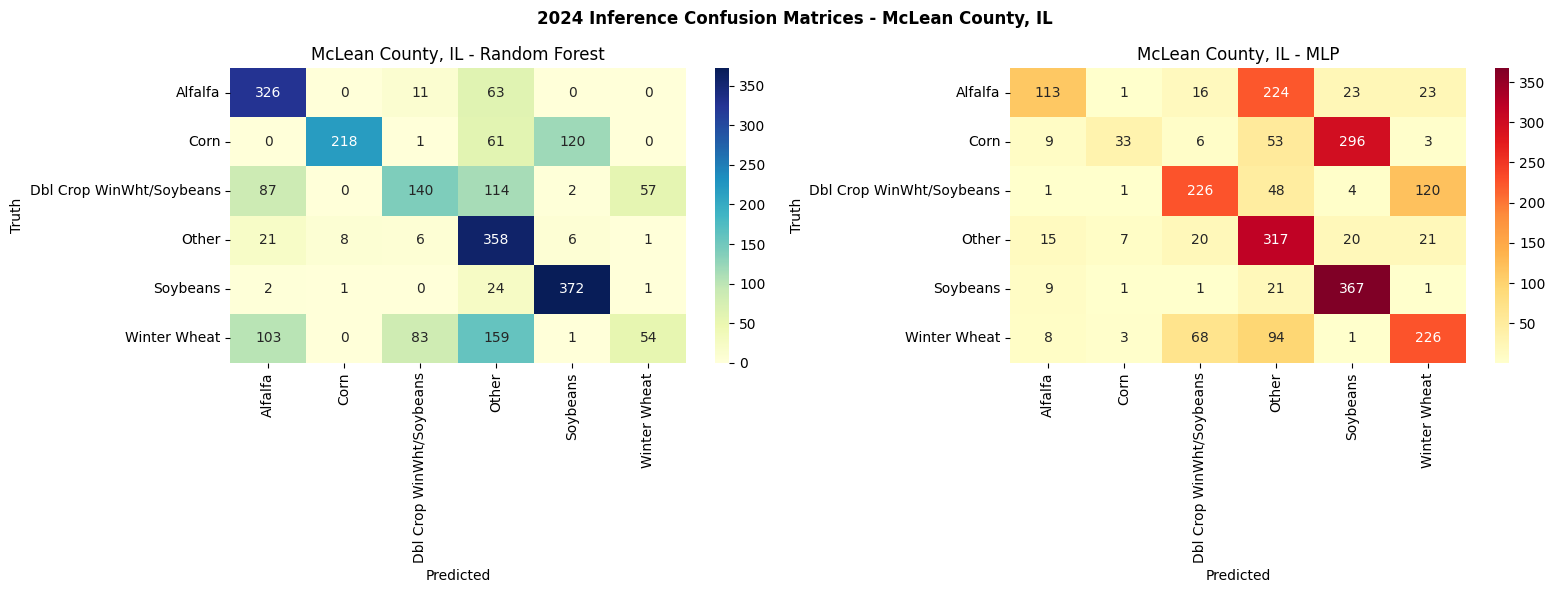


[Renville County, MN] RF classification report
                          precision    recall  f1-score   support

                 Alfalfa       0.94      0.91      0.92       400
                    Corn       0.86      0.51      0.64       400
Dbl Crop WinWht/Soybeans       0.00      0.00      0.00         0
                   Other       0.56      0.70      0.62       400
                Soybeans       0.64      0.85      0.73       400
            Winter Wheat       0.96      0.81      0.88       400

                accuracy                           0.76      2000
               macro avg       0.66      0.63      0.63      2000
            weighted avg       0.79      0.76      0.76      2000

[Renville County, MN] MLP classification report
                          precision    recall  f1-score   support

                 Alfalfa       0.77      0.38      0.51       400
                    Corn       0.59      0.21      0.31       400
Dbl Crop WinWht/Soybeans       0.00      0

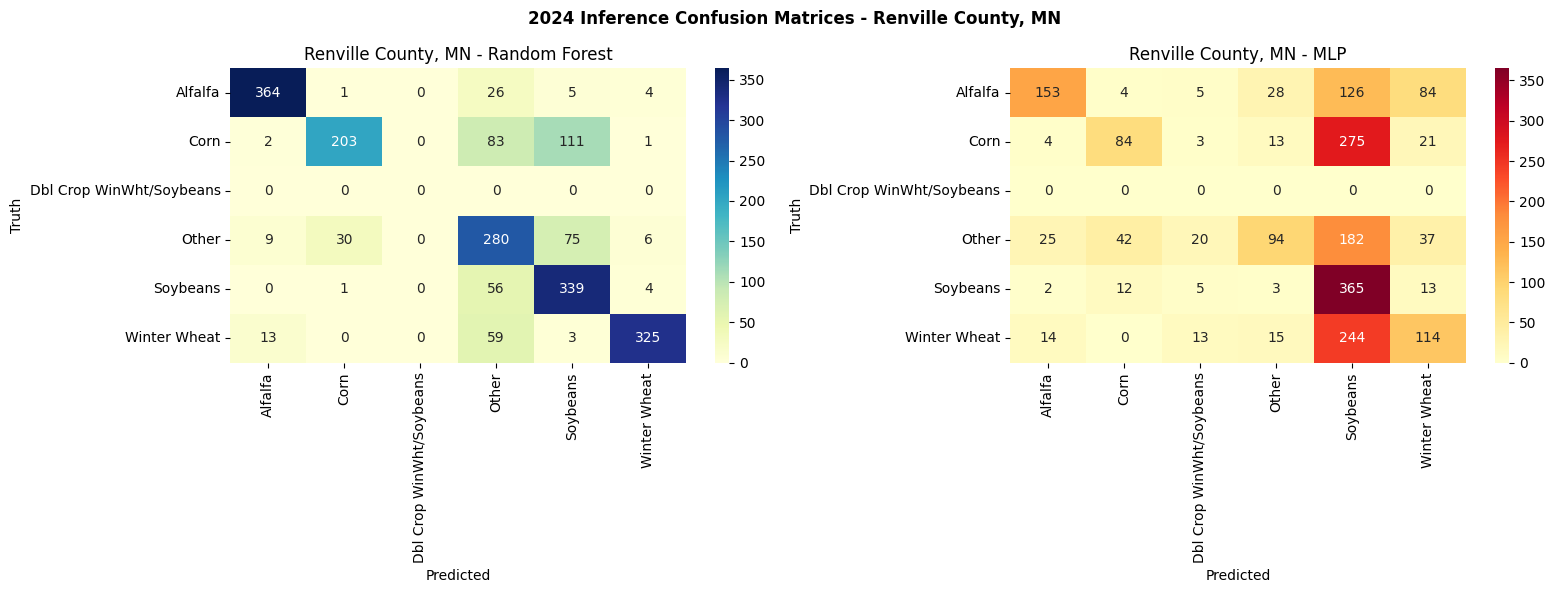

Random Forest agreement map (green = match, red = mismatch)


Map(center=[43.3, -91.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

MLP agreement map (green = match, red = mismatch)


Map(center=[43.3, -91.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [23]:
# Phase 4.5: Plot confusion heatmaps + geemap agreement maps (RF and MLP)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


GROUPED_LABELS = grouped_class_labels

def plot_county_confusions(county_name, df, class_order):
    y_true = df['truth_grouped']
    y_pred_rf = df['rf_pred_grouped']
    y_pred_mlp = df['mlp_pred_grouped']

    cm_rf = confusion_matrix(y_true, y_pred_rf, labels=class_order)
    cm_mlp = confusion_matrix(y_true, y_pred_mlp, labels=class_order)

    print(f"\n[{county_name}] RF classification report")
    print(classification_report(y_true, y_pred_rf, labels=class_order, zero_division=0))
    print(f"[{county_name}] MLP classification report")
    print(classification_report(y_true, y_pred_mlp, labels=class_order, zero_division=0))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_order, yticklabels=class_order, ax=ax1)
    ax1.set_title(f'{county_name} - Random Forest')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Truth')

    sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_order, yticklabels=class_order, ax=ax2)
    ax2.set_title(f'{county_name} - MLP')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Truth')

    plt.suptitle(f'2024 Inference Confusion Matrices - {county_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()



def df_to_match_fc(df, county_name, pred_col):
    """Convert predictions to an ee.FeatureCollection with grouped match flags."""
    feats = []
    truth_col = 'truth_grouped'
    pred_group_col = 'rf_pred_grouped' if pred_col == 'rf_pred_name' else 'mlp_pred_grouped'

    for _, row in df.iterrows():
        lon = float(row['longitude'])
        lat = float(row['latitude'])
        is_match = int(row[truth_col] == row[pred_group_col])
        feats.append(
            ee.Feature(
                ee.Geometry.Point([lon, lat]),
                {
                    'county': county_name,
                    'match': is_match,
                    'truth': str(row[truth_col]),
                    'pred': str(row[pred_group_col]),
                },
            )
        )
    return ee.FeatureCollection(feats)



def build_agreement_map(pred_col, map_title):
    geemap.coreutils.get_google_maps_api_key = lambda key='GOOGLE_MAPS_API_KEY': None
    agreement_map = geemap.Map(center=[43.3, -91.5], zoom=6)

    agreement_map.addLayer(mclean_top5, {'min': 1, 'max': 5, 'palette': top5_palette}, 'McLean CDL Top-5', False)
    agreement_map.addLayer(renville_top5, {'min': 1, 'max': 5, 'palette': top5_palette}, 'Renville CDL Top-5', False)
    agreement_map.addLayer(mclean_geom_layer, {}, 'McLean Boundary', True)
    agreement_map.addLayer(renville_geom_layer, {}, 'Renville Boundary', True)

    for county_name, county_df in county_results.items():
        fc = df_to_match_fc(county_df, county_name, pred_col)
        match_fc = fc.filter(ee.Filter.eq('match', 1))
        mismatch_fc = fc.filter(ee.Filter.eq('match', 0))

        agreement_map.addLayer(
            match_fc.style(**{'color': '00B050', 'pointSize': 2, 'width': 1}),
            {},
            f'{county_name} match ({pred_col})',
            True,
        )
        agreement_map.addLayer(
            mismatch_fc.style(**{'color': 'D62728', 'pointSize': 2, 'width': 1}),
            {},
            f'{county_name} mismatch ({pred_col})',
            True,
        )

    print(map_title)
    return agreement_map


for county_name, county_df in county_results.items():
    plot_county_confusions(county_name, county_df, GROUPED_LABELS)

rf_agreement_map = build_agreement_map('rf_pred_name', 'Random Forest agreement map (green = match, red = mismatch)')
display(rf_agreement_map)

mlp_agreement_map = build_agreement_map('mlp_pred_name', 'MLP agreement map (green = match, red = mismatch)')
display(mlp_agreement_map)

Analysis: Interestingly, the distribution of failure from above no longer seems to apply here. I believe that this is multifold; When training, we pass in an equal distribution of each point, which means that the models are not built around the inherent probability distribution of points in the CDL. As a result, points like Alfalfa, which are normally rare, are over-represented in my sampling for Part 4. What's also surprising is how performant the MLP is for these tasks: I expected considerable degrading due to overfitting (we are only training on ~~ 200 points).

However, > 50% accuracy for both sample classes is not bad, especially for a model with this little data. Understandably, as we discussed in class, the Random Forest dramatically outperforms the MLP here, at a margin far greater than seen during training. The MLP has degraded performance for both counties, while the Random Forest actually manages to maintain > 65% accuracy for both classes.


In a real application, spatially different inference would be less likely. Factors like soil type, weather, and other atmospheric conditions change how farmers plant, even while our indices reflect the same data. It makes sense that we have a decay in performance, though I'm surprised the drop off is not bigger. A 10% falloff is not terrible, considering the model cannot understand underlying land information.  